# Lesson 15: Data wrangling demonstration

This notebook demonstrates key data wrangling techniques for handling missing data and outliers.

**1. Aggregating and reshaping data**

- **groupby / agg**: Summarize data by category
- **pivot_table**: Cross-tabulate two categorical dimensions
- **melt**: Reshape wide format to long format
- **pivot**: Reshape long format to wide format

**2. Combining data**

- **concat**: Stack DataFrames vertically (more rows) or horizontally (more columns)
- **merge**: SQL-style joins on a shared key column (inner, left, right, outer)
- **join**: Join on the DataFrame index

**3. Handling missing data**

- **Mean imputation**: Replace missing values with the column mean
- **Median imputation**: Replace missing values with the column median
- **KNN imputation**: Use K-Nearest Neighbors to estimate missing values
- **Iterative imputation**: Model each feature as a function of others (MICE algorithm)

**4. Outlier detection methods**

- **IQR method**: Use interquartile range (Q3 - Q1) to identify outliers
- **Z-score method**: Identify values more than 3 standard deviations from the mean
- **Isolation Forest**: Machine learning algorithm that isolates anomalies
- **Local Outlier Factor (LOF)**: Density-based method comparing local density to neighbors

**5. Handling outliers**

- **Removal**: Remove outlier observations from the dataset
- **Capping (Winsorization)**: Replace outliers with boundary values (5th and 95th percentiles)
- **Binning (Discretization)**: Convert continuous values into discrete bins
- **Log transformation**: Apply logarithmic transformation to compress value range


## Setup

### Imports

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from matplotlib.gridspec import GridSpec
from scipy import stats
from sklearn.ensemble import IsolationForest
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import KNNImputer, IterativeImputer
from sklearn.neighbors import LocalOutlierFactor
from sklearn.preprocessing import KBinsDiscretizer

### Load datasets

In [2]:
df_original = pd.read_csv('https://gperdrizet.github.io/FSA_devops/assets/data/unit2/california_housing.csv')
df = pd.read_csv('https://gperdrizet.github.io/FSA_devops/assets/data/unit2/salted_housing_data.csv')
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,NaN,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,NaN,565.0,2.181467,37.85,NaN,3.422


### Define features

In [3]:
missing_feature = 'MedInc'
outlier_feature = 'MedHouseVal'

## 1. Aggregating and reshaping data

We'll use a small sales dataset throughout this section so each operation is easy to follow.

In [4]:
# Sample sales dataset, used throughout section 1
sales = pd.DataFrame({
    'region':   ['North', 'North', 'North', 'South', 'South', 'South',
                 'East',  'East',  'East',  'West',  'West',  'West'],
    'product':  ['A', 'B', 'C', 'A', 'B', 'C', 'A', 'B', 'C', 'A', 'B', 'C'],
    'quarter':  ['Q1', 'Q1', 'Q1', 'Q1', 'Q1', 'Q1',
                 'Q1', 'Q1', 'Q1', 'Q1', 'Q1', 'Q1'],
    'revenue':  [1200, 850, 430, 960, 1100, 310, 780, 920, 560, 1050, 670, 490],
    'units':    [60,   42,  21,  48,  55,   15,  39,  46,  28,  53,   33,  24],
})

# Add a second quarter for reshaping examples
q2 = sales.copy()
q2['quarter'] = 'Q2'
q2['revenue'] = (q2['revenue'] * np.random.uniform(0.85, 1.2, len(q2))).round().astype(int)
q2['units']   = (q2['units']   * np.random.uniform(0.85, 1.2, len(q2))).round().astype(int)
sales = pd.concat([sales, q2], ignore_index=True)

print(f"Shape: {sales.shape}")
sales.head(8)

Shape: (24, 5)


,region,product,quarter,revenue,units
0,North,A,Q1,1200,60
1,North,B,Q1,850,42
2,North,C,Q1,430,21
3,South,A,Q1,960,48
4,South,B,Q1,1100,55
5,South,C,Q1,310,15
6,East,A,Q1,780,39
7,East,B,Q1,920,46


### 1.1. groupby and aggregation

`groupby` splits the DataFrame into groups by one or more columns, then you apply an aggregation function to each group.

```
df.groupby('column')['value_column'].agg_function()
```

You can apply multiple aggregations at once with `.agg()`, and give the results custom names with **named aggregation**.

In [5]:
# Single aggregation: total revenue per region
print("Total revenue by region:")
print(sales.groupby('region')['revenue'].sum())
print()

# Multiple aggregations in one call
print("Revenue stats by region:")
print(sales.groupby('region')['revenue'].agg(['sum', 'mean', 'min', 'max']))

Total revenue by region:
region
East     4407
North    5095
South    4818
West     4416
Name: revenue, dtype: int64

Revenue stats by region:
         sum        mean  min   max
region                             
East    4407  734.500000  531   920
North   5095  849.166667  430  1210
South   4818  803.000000  310  1244
West    4416  736.000000  442  1050


In [6]:
# Named aggregation: group by two columns, give results readable names
summary = sales.groupby(['region', 'product']).agg(
    total_revenue = ('revenue', 'sum'),
    total_units   = ('units',   'sum'),
    avg_revenue   = ('revenue', 'mean'),
).reset_index()

print("Summary by region and product:")
print(summary)

Summary by region and product:
   region product  total_revenue  total_units  avg_revenue
0    East       A           1545           82        772.5
1    East       B           1771           90        885.5
2    East       C           1091           55        545.5
3   North       A           2410          112       1205.0
4   North       B           1791           91        895.5
5   North       C            894           43        447.0
6   South       A           1797           93        898.5
7   South       B           2344          116       1172.0
8   South       C            677           32        338.5
9    West       A           2014          114       1007.0
10   West       B           1470           68        735.0
11   West       C            932           50        466.0


### 1.2. pivot_table

`pivot_table` is like a spreadsheet pivot: it lets you cross-tabulate two categorical columns and fill the cells with an aggregated value.

```
pd.pivot_table(df, values='value', index='row_category', columns='col_category', aggfunc='sum')
```

Missing combinations are filled with `NaN` by default, or you can pass `fill_value=0`.

In [7]:
# Revenue cross-tabulation: regions as rows, products as columns
pivot = pd.pivot_table(
    sales,
    values='revenue',
    index='region',
    columns='product',
    aggfunc='sum',
    fill_value=0,
    margins=True,      # adds row/column totals
    margins_name='Total'
)
print("Revenue pivot table (region x product):")
print(pivot)
print()

# Units pivot with multiple quarters: region x quarter
units_pivot = pd.pivot_table(
    sales,
    values='units',
    index='region',
    columns='quarter',
    aggfunc='sum',
    fill_value=0
)
print("Units sold by region and quarter:")
print(units_pivot)

Revenue pivot table (region x product):
product     A     B     C  Total
region                          
East     1545  1771  1091   4407
North    2410  1791   894   5095
South    1797  2344   677   4818
West     2014  1470   932   4416
Total    7766  7376  3594  18736

Units sold by region and quarter:
quarter   Q1   Q2
region           
East     113  114
North    123  123
South    118  123
West     110  122


### 1.3. melt: wide to long

Many raw datasets arrive in **wide format**: one row per subject, with each observation as a separate column. Long format puts each observation on its own row, which is what most plotting libraries and ML pipelines expect.

`melt` converts wide to long:

```
df.melt(id_vars=['keep_these'], value_vars=['col1', 'col2'], var_name='variable', value_name='value')
```

In [8]:
# Wide format: one row per region, separate columns for Q1 and Q2 revenue
wide = pd.pivot_table(sales, values='revenue', index='region',
                      columns='quarter', aggfunc='sum').reset_index()
wide.columns.name = None   # tidy up the column label
print("Wide format (one row per region):")
print(wide)
print()

# melt to long format
long = wide.melt(
    id_vars='region',
    value_vars=['Q1', 'Q2'],
    var_name='quarter',
    value_name='revenue'
)
print("Long format (one row per region-quarter combination):")
print(long.sort_values(['region', 'quarter']).reset_index(drop=True))

Wide format (one row per region):
  region    Q1    Q2
0   East  2260  2147
1  North  2480  2615
2  South  2370  2448
3   West  2210  2206

Long format (one row per region-quarter combination):
  region quarter  revenue
0   East      Q1     2260
1   East      Q2     2147
2  North      Q1     2480
3  North      Q2     2615
4  South      Q1     2370
5  South      Q2     2448
6   West      Q1     2210
7   West      Q2     2206


### 1.4. pivot: long to wide

`pivot` is the reverse of `melt`. It takes a long-format DataFrame and spreads one column's values out as separate columns.

```
df.pivot(index='row_id', columns='variable_col', values='value_col')
```

Note: `pivot` requires that the combination of `index` and `columns` is unique. If you have duplicate combinations, use `pivot_table` instead (which can handle duplicates by aggregating them).

In [9]:
# Start from long format and pivot back to wide
wide_again = long.pivot(index='region', columns='quarter', values='revenue')
wide_again.columns.name = None
print("Pivoted back to wide format:")
print(wide_again)
print()

Pivoted back to wide format:
          Q1    Q2
region            
East    2260  2147
North   2480  2615
South   2370  2448
West    2210  2206



## 2. Combining data

Real-world data rarely arrives in a single table. Pandas gives you three main tools for combining DataFrames:

| Tool | When to use it |
|---|---|
| `pd.concat` | Stack DataFrames that have the **same columns** (more rows) or same rows (more columns) |
| `pd.merge` | Join two DataFrames on a **shared key column**, like a SQL JOIN |
| `df.join` | Join two DataFrames on their **index** |

We'll use a small set of related tables throughout this section.

In [10]:
# Three related tables used in section 2

# Orders placed in January
orders_jan = pd.DataFrame({
    'order_id':   [1, 2, 3, 4],
    'customer_id':[101, 102, 103, 101],
    'product':    ['Laptop', 'Mouse', 'Keyboard', 'Monitor'],
    'amount':     [1200, 25, 75, 300],
})

# Orders placed in February
orders_feb = pd.DataFrame({
    'order_id':   [5, 6, 7],
    'customer_id':[104, 102, 105],
    'product':    ['Webcam', 'Headset', 'Laptop'],
    'amount':     [80, 55, 1150],
})

# Customer details; note: customer 105 has no orders yet in Jan
customers = pd.DataFrame({
    'customer_id': [101, 102, 103, 104, 105],
    'name':        ['Alice', 'Bob', 'Carol', 'Dave', 'Eve'],
    'city':        ['London', 'Paris', 'Berlin', 'Madrid', 'Rome'],
})

# Loyalty tier table, only covers some customers
loyalty = pd.DataFrame({
    'customer_id': [101, 102, 104],
    'tier':        ['Gold', 'Silver', 'Bronze'],
})

print("orders_jan:"); print(orders_jan); print()
print("orders_feb:"); print(orders_feb); print()
print("customers:");  print(customers);  print()
print("loyalty:");    print(loyalty)

orders_jan:
   order_id  customer_id   product  amount
0         1          101    Laptop    1200
1         2          102     Mouse      25
2         3          103  Keyboard      75
3         4          101   Monitor     300

orders_feb:
   order_id  customer_id  product  amount
0         5          104   Webcam      80
1         6          102  Headset      55
2         7          105   Laptop    1150

customers:
   customer_id   name    city
0          101  Alice  London
1          102    Bob   Paris
2          103  Carol  Berlin
3          104   Dave  Madrid
4          105    Eve    Rome

loyalty:
   customer_id    tier
0          101    Gold
1          102  Silver
2          104  Bronze


### 2.1. concat: stacking DataFrames

`pd.concat` stacks DataFrames that share the same structure.

- `axis=0` (default): stack **vertically**, more rows, same columns. Use when you have the same data for different time periods or batches.
- `axis=1`: stack **horizontally**, more columns, same rows. Use when you want to add new feature columns alongside existing ones.

Pass `ignore_index=True` to get a clean, consecutive row index in the result.

In [11]:
# Vertical concat: combine January and February orders into one table
all_orders = pd.concat([orders_jan, orders_feb], ignore_index=True)
print("All orders (Jan + Feb stacked vertically):")
print(all_orders)
print(f"\nJan rows: {len(orders_jan)}  Feb rows: {len(orders_feb)}  Combined: {len(all_orders)}")
print()

# keys= labels which source each row came from, useful for tracking
all_orders_labelled = pd.concat(
    [orders_jan, orders_feb],
    keys=['January', 'February']
)
print("With source labels (multi-level index):")
print(all_orders_labelled)

All orders (Jan + Feb stacked vertically):
   order_id  customer_id   product  amount
0         1          101    Laptop    1200
1         2          102     Mouse      25
2         3          103  Keyboard      75
3         4          101   Monitor     300
4         5          104    Webcam      80
5         6          102   Headset      55
6         7          105    Laptop    1150

Jan rows: 4  Feb rows: 3  Combined: 7

With source labels (multi-level index):
            order_id  customer_id   product  amount
January  0         1          101    Laptop    1200
         1         2          102     Mouse      25
         2         3          103  Keyboard      75
         3         4          101   Monitor     300
February 0         5          104    Webcam      80
         1         6          102   Headset      55
         2         7          105    Laptop    1150


### 2.2. merge: joining on a shared key column

`pd.merge` joins two DataFrames on a common column, exactly like a SQL JOIN. The `how` parameter controls which rows are kept:

| `how` | Rows kept |
|---|---|
| `'inner'` | Only rows where the key exists in **both** tables (default) |
| `'left'` | All rows from the **left** table; `NaN` where no match in right |
| `'right'` | All rows from the **right** table; `NaN` where no match in left |
| `'outer'` | All rows from **both** tables; `NaN` wherever there is no match |

In [12]:
# Inner join: only orders that have a matching customer record
inner = pd.merge(all_orders, customers, on='customer_id', how='inner')
print("INNER join (orders + customers):")
print(inner)
print(f"Rows: {len(inner)}\n")

INNER join (orders + customers):
   order_id  customer_id   product  amount   name    city
0         1          101    Laptop    1200  Alice  London
1         2          102     Mouse      25    Bob   Paris
2         3          103  Keyboard      75  Carol  Berlin
3         4          101   Monitor     300  Alice  London
4         5          104    Webcam      80   Dave  Madrid
5         6          102   Headset      55    Bob   Paris
6         7          105    Laptop    1150    Eve    Rome
Rows: 7



In [13]:
# Left join: keep all orders, add loyalty tier where it exists, NaN where not
left = pd.merge(all_orders, loyalty, on='customer_id', how='left')
print("LEFT join (all orders + loyalty tier where available):")
print(left)
print(f"Rows: {len(left)}  (same as all_orders, no orders dropped)\n")

LEFT join (all orders + loyalty tier where available):
   order_id  customer_id   product  amount    tier
0         1          101    Laptop    1200    Gold
1         2          102     Mouse      25  Silver
2         3          103  Keyboard      75     NaN
3         4          101   Monitor     300    Gold
4         5          104    Webcam      80  Bronze
5         6          102   Headset      55  Silver
6         7          105    Laptop    1150     NaN
Rows: 7  (same as all_orders, no orders dropped)



In [14]:
# Outer join: all customers, whether or not they placed an order
outer = pd.merge(customers, all_orders, on='customer_id', how='outer')
print("OUTER join (all customers + all orders, NaN where no match):")
print(outer.sort_values('customer_id').reset_index(drop=True))

OUTER join (all customers + all orders, NaN where no match):
   customer_id   name    city  order_id   product  amount
0          101  Alice  London         1    Laptop    1200
1          101  Alice  London         4   Monitor     300
2          102    Bob   Paris         2     Mouse      25
3          102    Bob   Paris         6   Headset      55
4          103  Carol  Berlin         3  Keyboard      75
5          104   Dave  Madrid         5    Webcam      80
6          105    Eve    Rome         7    Laptop    1150


### 2.3. join: joining on the index

`df.join` is a convenience wrapper around `merge` that joins on the DataFrame **index** rather than a named column. It defaults to a left join.

It is most useful when you have already set the key column as the index with `.set_index()`, or when you want to quickly attach lookup columns to an existing table.

In [15]:
# Set customer_id as the index on both tables
customers_idx = customers.set_index('customer_id')
loyalty_idx   = loyalty.set_index('customer_id')

# join: attach loyalty tier to customer info (left join on index by default)
result = customers_idx.join(loyalty_idx, how='left')
print("customers.join(loyalty): left join on customer_id index:")
print(result)
print()

# Equivalent merge, produces the same result
equiv = pd.merge(customers, loyalty, on='customer_id', how='left').set_index('customer_id')
print("Equivalent merge result (identical):")
print(equiv)
print()
print("Results identical:", result.equals(equiv))

customers.join(loyalty): left join on customer_id index:
              name    city    tier
customer_id                       
101          Alice  London    Gold
102            Bob   Paris  Silver
103          Carol  Berlin     NaN
104           Dave  Madrid  Bronze
105            Eve    Rome     NaN

Equivalent merge result (identical):
              name    city    tier
customer_id                       
101          Alice  London    Gold
102            Bob   Paris  Silver
103          Carol  Berlin     NaN
104           Dave  Madrid  Bronze
105            Eve    Rome     NaN

Results identical: True


### 2.4. When to use which

| Situation | Best tool |
|---|---|
| Same columns, more rows (e.g. monthly batches) | `pd.concat(axis=0)` |
| Same rows, more columns (e.g. adding feature blocks) | `pd.concat(axis=1)` |
| Join on a named key column, need to control which rows to keep | `pd.merge` |
| Join on the index, or a quick left-join lookup | `df.join` |

A common real-world workflow is to use `pd.concat` to stack batches of raw data, then use `pd.merge` to enrich it with lookup tables (e.g. product names, region codes, customer tiers).

## 3. Handling missing data

We'll examine missing data in the `MedInc` (median income) feature and compare four imputation methods.

In [16]:
df_original = pd.read_csv('https://media.githubusercontent.com/media/gperdrizet/fullstack-2605/refs/heads/main/data/california_housing.csv')
df = pd.read_csv('https://media.githubusercontent.com/media/gperdrizet/fullstack-2605/refs/heads/main/data/salted_housing_data.csv')

df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,NaN,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,NaN,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,NaN,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [17]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       19775 non-null  float64
 1   HouseAge     19857 non-null  float64
 2   AveRooms     18671 non-null  float64
 3   AveBedrms    20044 non-null  float64
 4   Population   19649 non-null  float64
 5   AveOccup     18684 non-null  float64
 6   Latitude     18885 non-null  float64
 7   Longitude    18798 non-null  float64
 8   MedHouseVal  20370 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [18]:
missing_feature = 'MedInc'
outlier_feature = 'MedHouseVal'

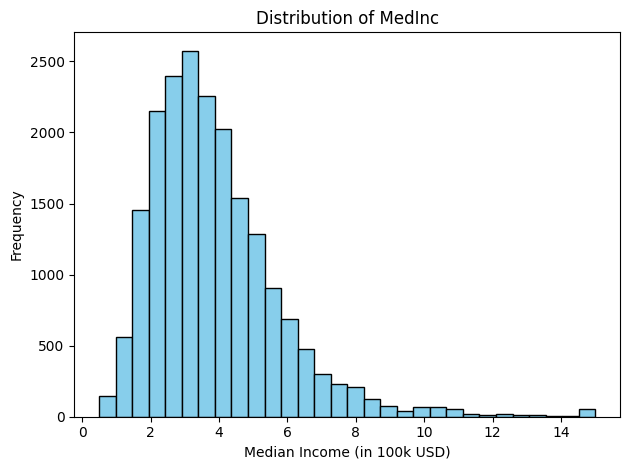

In [19]:
plt.title(f'Distribution of {missing_feature}')

plt.hist(df[missing_feature], bins=30, color='skyblue', edgecolor='black')
plt.xlabel('Median Income (in 100k USD)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

### 3.1. Check for missing values

In [20]:
print(f'{missing_feature} contains {df[missing_feature].isnull().sum()} missing values.')

MedInc contains 865 missing values.


### 3.2. Imputation methods

#### Mean imputation

In [21]:
df_mean = df.copy()
df_mean.fillna({missing_feature: df_mean[missing_feature].mean()}, inplace=True)

print(f"Mean imputation value: {df[missing_feature].mean():.2f}")

Mean imputation value: 3.87


#### Median imputation

In [22]:
df_median = df.copy()
df_median.fillna({missing_feature: df_median[missing_feature].median()}, inplace=True)

print(f"Median imputation value: {df[missing_feature].median():.2f}")

Median imputation value: 3.53


#### KNN imputation

Uses all features to find the 5 nearest neighbors and imputes missing values based on their feature values.

In [23]:
knn_imputer = KNNImputer(n_neighbors=5)
df_knn_full = knn_imputer.fit_transform(df)

# Extract the feature of interest
df_knn = pd.DataFrame(
    df_knn_full[:, df.columns.get_loc(missing_feature)],
    columns=[missing_feature],
    index=df.index
)

print(f"KNN imputation uses 5 nearest neighbors across all {len(df.columns)} features")

KNN imputation uses 5 nearest neighbors across all 9 features


#### Iterative imputation

Models each feature as a function of others through multiple iterations, capturing multivariate relationships.

In [24]:
iterative_imputer = IterativeImputer(max_iter=10, random_state=42)
df_iterative_full = iterative_imputer.fit_transform(df)

# Extract the feature of interest
df_iterative = pd.DataFrame(
    df_iterative_full[:, df.columns.get_loc(missing_feature)],
    columns=[missing_feature],
    index=df.index
)

print(f"Iterative imputation models relationships across all {len(df.columns)} features")

Iterative imputation models relationships across all 9 features


### 3.3. Compare imputation results

Visualize how each imputation method affects the distribution of `MedInc`.

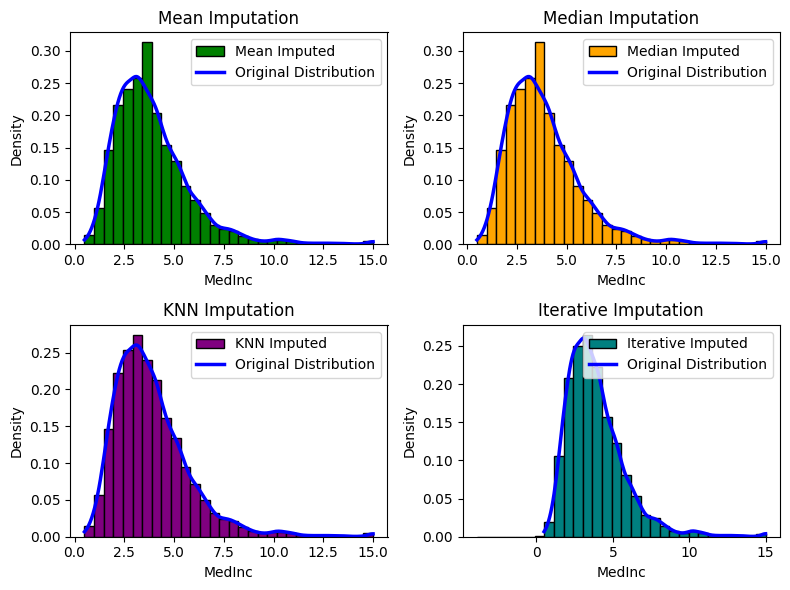

In [25]:
fig, axes = plt.subplots(2, 2, figsize=(8, 6))
axes = axes.flatten()

# Create KDE of original distribution
kde_original = stats.gaussian_kde(df[missing_feature].dropna())
x_range = np.linspace(df[missing_feature].min(), df[missing_feature].max(), 200)
kde_values = kde_original(x_range)

# Define imputation methods and their properties
imputation_methods = [
    {'data': df_mean, 'title': 'Mean Imputation', 'color': 'green', 'label': 'Mean Imputed'},
    {'data': df_median, 'title': 'Median Imputation', 'color': 'orange', 'label': 'Median Imputed'},
    {'data': df_knn, 'title': 'KNN Imputation', 'color': 'purple', 'label': 'KNN Imputed'},
    {'data': df_iterative, 'title': 'Iterative Imputation', 'color': 'teal', 'label': 'Iterative Imputed'}
]

# Plot each imputation method
for idx, method in enumerate(imputation_methods):
    ax = axes[idx]
    
    ax.set_title(method['title'])
    ax.hist(
        method['data'][missing_feature],
        bins=30, density=True,
        edgecolor='black', color=method['color'],
        label=method['label']
    )
    ax.plot(
        x_range, kde_values,
        'b-', linewidth=2.5,
        label='Original Distribution'
    )
    ax.set_xlabel(missing_feature)
    ax.set_ylabel('Density')
    ax.legend(loc='upper right')

plt.tight_layout()
plt.show()

## 4. Outlier detection methods

This section demonstrates four common methods for detecting outliers:

- **IQR method**: Use interquartile range (Q3 - Q1) to identify outliers
- **Z-score method**: Identify values more than 3 standard deviations from the mean
- **Isolation Forest**: Machine learning algorithm that isolates anomalies
- **Local Outlier Factor (LOF)**: Density-based method comparing local density to neighbors

In [26]:
outlier_feature = 'MedInc'

### 4.1. Visualize feature distribution

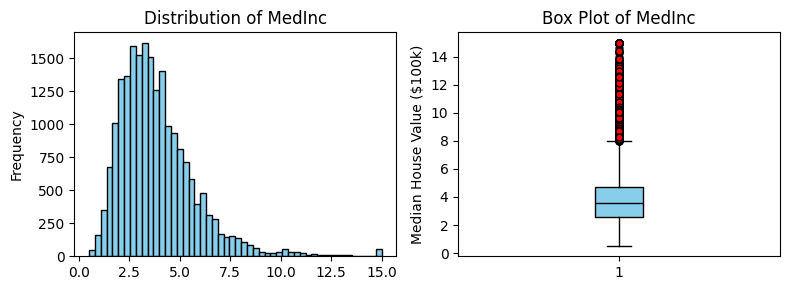

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(8, 3))

# Histogram
axes[0].set_title(f'Distribution of {outlier_feature}')

axes[0].hist(
    df_original[outlier_feature],
    bins=50,
    color='skyblue',
    edgecolor='black',
)

axes[0].set_xlabel('Median House Value ($100k)')
axes[0].set_ylabel('Frequency')

# Box plot
axes[1].set_title(f'Box Plot of {outlier_feature}')

axes[1].boxplot(
    df_original[outlier_feature],
    vert=True,
    patch_artist=True,
    boxprops=dict(facecolor='skyblue'),
    medianprops=dict(color='black'),
    flierprops=dict(marker='o', markerfacecolor='red', markersize=5)
)

axes[1].set_ylabel('Median House Value ($100k)')
axes[0].set_xlabel('')

plt.tight_layout()
plt.show()

### 4.2. IQR (interquartile range) method

Defines outliers as values below Q1 - 1.5×IQR or above Q3 + 1.5×IQR.

In [28]:
def detect_outliers_iqr(data, column, multiplier=1.5):
    """
    Detect outliers using the IQR method.
    
    Parameters:
    - data: DataFrame
    - column: column name to check for outliers
    - multiplier: IQR multiplier (typically 1.5 for outliers, 3.0 for extreme outliers)
    
    Returns:
    - Boolean series indicating outliers
    """

    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - multiplier * IQR
    upper_bound = Q3 + multiplier * IQR
    
    outliers = (data[column] < lower_bound) | (data[column] > upper_bound)
    
    return outliers

outliers_iqr = detect_outliers_iqr(df_original, outlier_feature)

### 4.3. Z-score method

Identifies outliers as values with |z-score| > 3, meaning they are more than 3 standard deviations from the mean.

In [29]:
def detect_outliers_zscore(data, column, threshold=3):
    """
    Detect outliers using the Z-Score method.
    
    Parameters:
    - data: DataFrame
    - column: column name to check for outliers
    - threshold: z-score threshold (typically 3)
    
    Returns:
    - Boolean series indicating outliers
    """

    mean = data[column].mean()
    std = data[column].std()
    z_scores = np.abs((data[column] - mean) / std)
    
    outliers = z_scores > threshold
    
    return outliers

outliers_zscore = detect_outliers_zscore(df_original, outlier_feature)

### 4.4. Isolation Forest

Machine learning algorithm designed for anomaly detection that randomly partitions data to identify points that are quickly isolated.

In [30]:
def detect_outliers_isolation_forest(data, column, contamination=0.05):
    """
    Detect outliers using Isolation Forest.
    
    Parameters:
    - data: DataFrame
    - column: column name to check for outliers
    - contamination: expected proportion of outliers (default 0.05 = 5%)
    
    Returns:
    - Boolean series indicating outliers
    """
    # Isolation Forest requires 2D array
    X = data[[column]].values
    
    iso_forest = IsolationForest(contamination=contamination, random_state=42)
    predictions = iso_forest.fit_predict(X)
    
    # Isolation Forest returns -1 for outliers, 1 for inliers
    outliers = predictions == -1
    
    return outliers

outliers_iforest = detect_outliers_isolation_forest(df_original, outlier_feature, contamination=0.025)

### 4.5. Local Outlier Factor (LOF)

Identifies outliers by measuring local density deviation relative to neighbors. Points with substantially lower density than their neighbors are flagged as outliers.

In [31]:
def detect_outliers_lof(data, column, n_neighbors=1000):
    """
    Detect outliers using Local Outlier Factor.
    
    Parameters:
    - data: DataFrame
    - column: column name to check for outliers
    - n_neighbors: number of neighbors to consider (default 1000)
    
    Returns:
    - Boolean series indicating outliers
    """

    # LOF requires 2D array
    X = data[[column]].values
    
    lof = LocalOutlierFactor(n_neighbors=n_neighbors)
    predictions = lof.fit_predict(X)
    
    # LOF returns -1 for outliers, 1 for inliers
    outliers = predictions == -1

    return outliers

outliers_lof = detect_outliers_lof(df_original, outlier_feature)

### 4.6. Compare outlier detection methods

Visualize how each method identifies outliers in the feature.

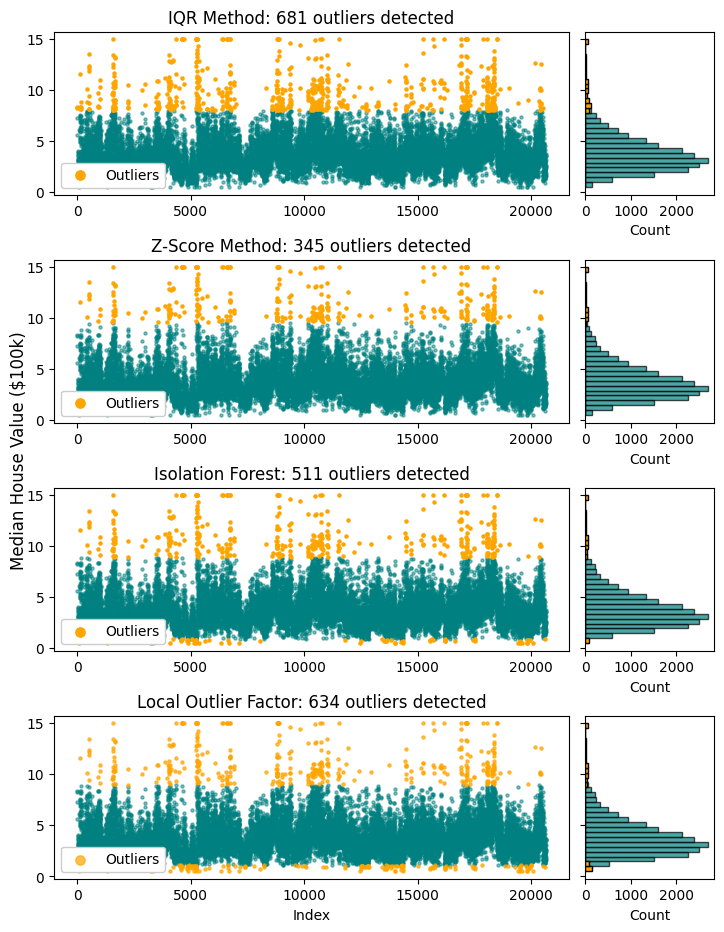

In [32]:
# Precompute 30 bins for consistent histogram display across all methods
n_hist_bins = 30

hist_bins = np.linspace(
    df_original[outlier_feature].min(), 
    df_original[outlier_feature].max(), 
    n_hist_bins + 1
)

fig = plt.figure(figsize=(8, 11))
gs = GridSpec(4, 2, figure=fig, width_ratios=[4, 1], hspace=0.4, wspace=0.05)
fig.supylabel('Median House Value ($100k)')

# Define detection methods
detection_methods = [
    {'outliers': outliers_iqr, 'title': 'IQR Method'},
    {'outliers': outliers_zscore, 'title': 'Z-Score Method'},
    {'outliers': outliers_iforest, 'title': 'Isolation Forest'},
    {'outliers': outliers_lof, 'title': 'Local Outlier Factor'}
]

# Plot each detection method
for idx, method in enumerate(detection_methods):
    outliers = method['outliers']
    
    # Scatter plot
    ax_scatter = fig.add_subplot(gs[idx, 0])
    ax_scatter.set_title(f"{method['title']}: {outliers.sum()} outliers detected")
    
    ax_scatter.scatter(
        df_original.index[~outliers],
        df_original.loc[~outliers, outlier_feature], 
        c='teal', alpha=0.5, s=5
    )
    
    ax_scatter.scatter(
        df_original.index[outliers],
        df_original.loc[outliers, outlier_feature], 
        c='orange', alpha=0.7 if idx == 3 else 1.0, s=5, label='Outliers'
    )
    
    if idx == 3:  # Last plot gets x-label
        ax_scatter.set_xlabel('Index')
    ax_scatter.set_ylabel('')
    ax_scatter.legend(loc='lower left', framealpha=1, markerscale=3)
    
    # Histogram
    ax_hist = fig.add_subplot(gs[idx, 1], sharey=ax_scatter)
    ax_hist.hist(
        df_original.loc[~outliers, outlier_feature],
        bins=hist_bins, orientation='horizontal', 
        color='teal', alpha=0.7, edgecolor='black'
    )
    
    ax_hist.hist(
        df_original.loc[outliers, outlier_feature],
        bins=hist_bins, orientation='horizontal', 
        color='orange', edgecolor='black'
    )
    
    ax_hist.tick_params(labelleft=False)
    ax_hist.set_xlabel('Count', fontsize=10)

plt.subplots_adjust(left=0.075)
plt.show()

## 5. Handling outliers

Once outliers are detected, we must decide how to handle them. This section demonstrates four common approaches:

- **Removal**: Remove outlier observations from the dataset
- **Capping (Winsorization)**: Replace outliers with boundary values (5th and 95th percentiles)
- **Binning (Discretization)**: Convert continuous values into discrete bins
- **Log transformation**: Apply logarithmic transformation to compress value range

### 5.1. Removal

Remove outliers identified by the IQR method from the dataset.

In [33]:
# Method 1: Remove outliers
df_removed = df_original[~outliers_iqr].copy()

### 5.2. Capping (Winsorization)

Cap outliers at the 5th and 95th percentiles, preserving sample size while limiting extreme values.

In [34]:
# Method 2: Cap outliers at percentiles
lower_percentile = df_original[outlier_feature].quantile(0.05)
upper_percentile = df_original[outlier_feature].quantile(0.95)

df_capped = df_original.copy()
df_capped[outlier_feature] = df_capped[outlier_feature].clip(lower=lower_percentile, upper=upper_percentile)

# Count how many values were capped
n_capped_lower = (df_original[outlier_feature] < lower_percentile).sum()
n_capped_upper = (df_original[outlier_feature] > upper_percentile).sum()

### 5.3. Binning (discretization)

Convert continuous values into discrete quantile bins, reducing outlier impact by grouping extreme values with similar values.

In [35]:
# Method 3: Binning into 10 equal-width bins
df_binned = df_original.copy()

# Create equal-width bins using sklearn
n_bins = 10
kbd = KBinsDiscretizer(n_bins=n_bins, encode='ordinal', strategy='quantile', quantile_method='linear')

# Fit and transform the data
df_binned[f'{outlier_feature}_binned_numeric'] = kbd.fit_transform(
    df_binned[[outlier_feature]]
).astype(int) + 1  # Add 1 to start bins at 1 instead of 0

# Extract bin edges for visualization
bin_edges = kbd.bin_edges_[0]

### 5.4. Log transformation

Apply log(1 + x) transformation to compress the value range and reduce outlier impact.

In [36]:
# Method 4: Log transformation
df_log = df_original.copy()

# Apply log1p transformation (log(1 + x)) to handle zeros
df_log[f'{outlier_feature}_log'] = np.log1p(df_log[outlier_feature])

### 5.5. Compare outlier handling methods

Visualize how each method affects the distribution of `MedHouseVal`, with the original distribution overlaid for comparison.

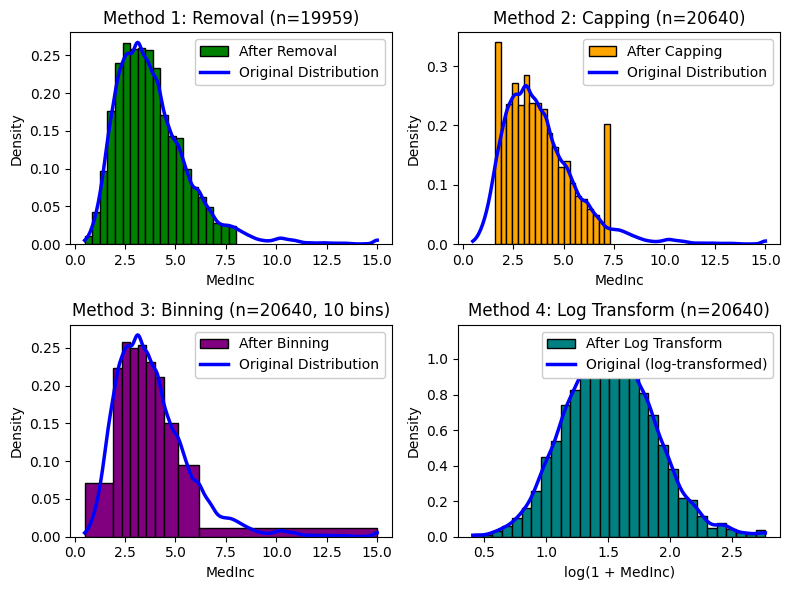

In [38]:
fig, axes = plt.subplots(2, 2, figsize=(8, 6))
axes = axes.flatten()

# Create KDE of original distribution with small bandwidth to preserve outlier spike
kde_original = stats.gaussian_kde(df_original[outlier_feature].dropna(), bw_method=0.1)
x_range = np.linspace(df_original[outlier_feature].min(), df_original[outlier_feature].max(), 300)
kde_values = kde_original(x_range)

# Create KDE for log-transformed original distribution
kde_original_log = stats.gaussian_kde(np.log1p(df_original[outlier_feature].dropna()), bw_method=0.15)
x_range_log = np.linspace(df_log[f'{outlier_feature}_log'].min(), df_log[f'{outlier_feature}_log'].max(), 300)
kde_values_log = kde_original_log(x_range_log)

# Define handling methods
handling_methods = [
    {'data': df_removed[outlier_feature], 'title': f'Method 1: Removal (n={len(df_removed)})', 
     'color': 'green', 'label': 'After Removal', 'bins': 20, 
     'x_range': x_range, 'kde_values': kde_values, 'xlabel': outlier_feature},
    {'data': df_capped[outlier_feature], 'title': f'Method 2: Capping (n={len(df_capped)})', 
     'color': 'orange', 'label': 'After Capping', 'bins': 20,
     'x_range': x_range, 'kde_values': kde_values, 'xlabel': outlier_feature},
    {'data': df_binned[outlier_feature], 'title': f'Method 3: Binning (n={len(df_binned)}, {n_bins} bins)', 
     'color': 'purple', 'label': 'After Binning', 'bins': bin_edges,
     'x_range': x_range, 'kde_values': kde_values, 'xlabel': outlier_feature},
    {'data': df_log[f'{outlier_feature}_log'], 'title': f'Method 4: Log Transform (n={len(df_log)})', 
     'color': 'teal', 'label': 'After Log Transform', 'bins': 30,
     'x_range': x_range_log, 'kde_values': kde_values_log, 'xlabel': f'log(1 + {outlier_feature})'}
]

# Plot each handling method
for idx, method in enumerate(handling_methods):
    ax = axes[idx]
    
    ax.set_title(method['title'])
    ax.hist(
        method['data'],
        bins=method['bins'], edgecolor='black', color=method['color'],
        density=True, label=method['label']
    )
    
    ax.plot(
        method['x_range'], method['kde_values'],
        'b-', linewidth=2.5,
        label='Original (log-transformed)' if idx == 3 else 'Original Distribution'
    )
    
    ax.set_xlabel(method['xlabel'])
    ax.set_ylabel('Density')
    ax.legend(loc='upper right', framealpha=1, markerscale=3)

plt.tight_layout()
plt.show()